# Phase 6 — Notebook 23: CSE-CIC-IDS2018 feature geometry (G-GEOM gate) — **re-run v2**

**Notebook:** `notebooks/08_phase6_cse2018/23_cse2018_geometry.ipynb`
**Pre-registration:** `reports/advisor_notes/PREREG_cse2018.md` + **Addendum A1** (deviation A1.0: `attempted_category` removed from features).
**This is the post-fix re-run.** Expected changes vs the first run: `n_features` 83 → **82**; median redundancy and leakage floor essentially unchanged (the removed column was degenerate and never entered the correlation math). Predictions re-tested: **P1** (median redundancy ≥ 0.85), **P2** (leakage floor ≥ 0.20).

Implements thesis **Defs. 1–3 verbatim**:
- **Def. 1 (redundancy):** R(i) = max_{j≠i} |corr(X·i, X·j)| on the standardised matrix.
- **Def. 2 (external leakage):** L(S) = mean over i∈S of max_{j∉S} C_ij; decorrelated iff L(S) ≤ τ = 0.20.
- **Def. 3 (non-degeneracy):** top value ≤ 0.90 of rows AND ≥ 20 distinct values.

**Decision rule (pre-registered, G-GEOM):**
- No decorrelated non-degenerate size-5 target reachable → **R2 replicates** → proceed to notebooks 24/25.
- Such a target **is** reachable → **STOP**; prereg addendum for the C4-promotion experiment first.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.insert(0, '/content/drive/MyDrive/phd_thesis')

import json
import numpy as np
import pandas as pd
from pathlib import Path

from src.data.loaders import load_dataset
from src.utils.seeding import set_global_seed

set_global_seed(42)
ROOT = Path('/content/drive/MyDrive/phd_thesis')

TAU = 0.20                 # Def. 2 decorrelation threshold
TARGET_SIZE = 5            # matches thesis size-5 target search
NONDEG_TOPFRAC = 0.90      # Def. 3
NONDEG_MIN_DISTINCT = 20   # Def. 3
SAMPLE_N = 300_000         # correlation-matrix sample, seeded
N_GREEDY_SEEDS = 20        # greedy floor search restarts

Mounted at /content/drive


## 2. Load, **leakage guard**, and sample

The guard is the whole point of the re-run: if any label-adjacent column
(`attempted_category`, anything containing `label`/`attempted`/`category`)
is still inside X, the notebook stops here — that means Stage 2 of
notebook 05 was not re-run after the fix, or old parquets survive in
`data/processed/cse_cic_ids2018/`.

In [2]:
X, y, meta = load_dataset('cse_cic_ids2018')
print('full:', X.shape)

FORBIDDEN_SUBSTRINGS = ('label', 'attempted', 'attack', 'category')
leaked = [c for c in X.columns
          if any(s in c.lower() for s in FORBIDDEN_SUBSTRINGS)]
assert not leaked, (
    f'LABEL-ADJACENT COLUMNS STILL IN FEATURES: {leaked}. '
    f'Re-run notebook 05 Stage 2 after adding them to the drop list, '
    f'and delete stale parquets in data/processed/cse_cic_ids2018/.')
assert X.shape[1] == 82, (
    f'Expected 82 features post-fix, got {X.shape[1]} — investigate before '
    f'proceeding (A1.0 records 83 -> 82).')
print('leakage guard passed: 82 clean flow features')

if len(X) > SAMPLE_N:
    idx = np.random.RandomState(42).choice(len(X), SAMPLE_N, replace=False)
    X = X.iloc[idx]
print('sampled:', X.shape)

full: (15000001, 82)
leakage guard passed: 82 clean flow features
sampled: (300000, 82)


## 3. Def. 3 — non-degeneracy screen

In [3]:
top_frac = X.apply(lambda col: col.value_counts(normalize=True).iloc[0])
n_distinct = X.nunique()
nd_mask = (top_frac <= NONDEG_TOPFRAC) & (n_distinct >= NONDEG_MIN_DISTINCT)
nd_features = X.columns[nd_mask].tolist()

degenerate = pd.DataFrame({'top_frac': top_frac[~nd_mask].round(3),
                           'n_distinct': n_distinct[~nd_mask]})
print(f'features: {X.shape[1]} | non-degenerate: {len(nd_features)}')
print('\ndegenerate features:')
display(degenerate.sort_values('top_frac', ascending=False))

features: 82 | non-degenerate: 60

degenerate features:


,top_frac,n_distinct
fwd_urg_flags,1.000,1
bwd_urg_flags,1.000,1
urg_flag_count,1.000,1
subflow_bwd_packets,0.999,2
icmp_type,0.998,5
icmp_code,0.998,7
fwd_packet_bulk_avg,0.994,65
fwd_bulk_rate_avg,0.994,1885
fwd_bytes_bulk_avg,0.994,1084
subflow_fwd_packets,0.987,2


## 4. Defs. 1–2 — redundancy R(i), leakage L(S), greedy floor search

In [4]:
Z = (X[nd_features] - X[nd_features].mean()) / X[nd_features].std(ddof=0)
C = np.abs(np.corrcoef(Z.to_numpy(), rowvar=False))
np.fill_diagonal(C, 0.0)
C = np.nan_to_num(C)

R = C.max(axis=1)                                  # Def. 1
median_redundancy = float(np.median(R))

def external_leakage(members):                     # Def. 2 (Eq. 1)
    outside = np.setdiff1d(np.arange(C.shape[0]), members)
    return float(np.mean([C[i, outside].max() for i in members]))

def greedy_floor(seed_feature):
    S = [int(seed_feature)]
    while len(S) < TARGET_SIZE:
        best, best_L = None, np.inf
        for j in np.argsort(R):
            if j in S: continue
            L = external_leakage(S + [int(j)])
            if L < best_L: best, best_L = int(j), L
        S.append(best)
    return S, external_leakage(S)

candidates = [greedy_floor(s) for s in np.argsort(R)[:N_GREEDY_SEEDS]]
best_S, floor = min(candidates, key=lambda t: t[1])
best_names = [nd_features[i] for i in best_S]

print(f'median redundancy (non-degenerate): {median_redundancy:.3f}')
print(f'external-leakage floor (best size-{TARGET_SIZE}): {floor:.3f}')
print(f'best set: {best_names}')

median redundancy (non-degenerate): 0.969
external-leakage floor (best size-5): 0.365
best set: ['bwd_header_length', 'flow_bytes_s', 'total_tcp_flow_time', 'fwd_init_win_bytes', 'fwd_header_length']


## 5. Redundancy distribution figure (paper/thesis asset)

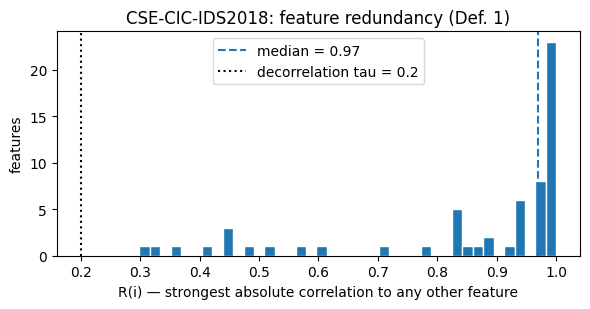

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.hist(R, bins=40, edgecolor='white')
ax.axvline(median_redundancy, ls='--', label=f'median = {median_redundancy:.2f}')
ax.axvline(TAU, color='k', ls=':', label=f'decorrelation tau = {TAU}')
ax.set_xlabel('R(i) — strongest absolute correlation to any other feature')
ax.set_ylabel('features'); ax.legend()
ax.set_title('CSE-CIC-IDS2018: feature redundancy (Def. 1)')
fig.tight_layout()
for ext in ['png', 'pdf']:
    fig.savefig(ROOT / 'reports' / 'figures' / f'23_cse2018_redundancy_hist.{ext}', dpi=200)
plt.show()

## 6. Pre-registered decision rule (G-GEOM) and outputs

Overwrites the v1 geometry row (`data/processed/phase6_23_cse2018_geometry.json`
+ `reports/tables/23_cse2018_geometry.csv`). The v1 numbers (83 features,
median 0.969, floor 0.365) remain recorded in Addendum A1.0 and the findings
log — the fix is documented, not hidden.

In [6]:
reachable = floor <= TAU
verdict = ('DECORRELATED-TARGET-REACHABLE — STOP: write the PREREG addendum '
           'for the C4-promotion experiment before running anything on this target.'
           if reachable else
           'UNREACHABLE-REGIME-CONFIRMED — R2 replicates on a third dataset; '
           'proceed to notebooks 24/25.')

row = {'dataset': 'cse_cic_ids2018',
       'run_version': 'v2_post_attempted_category_fix (A1.0)',
       'n_features': int(X.shape[1]),
       'n_nondegenerate': int(len(nd_features)),
       'median_redundancy': round(median_redundancy, 3),
       'leakage_floor_size5': round(floor, 3),
       'decorrelated_target_reachable': bool(reachable),
       'best_size5_set': best_names,
       'prereg_P1_holds (median >= 0.85)': bool(median_redundancy >= 0.85),
       'prereg_P2_holds (floor >= 0.20)': bool(floor >= TAU),
       'verdict': verdict}

with open(ROOT / 'data' / 'processed' / 'phase6_23_cse2018_geometry.json', 'w') as f:
    json.dump(row, f, indent=2)
pd.DataFrame([row]).to_csv(ROOT / 'reports' / 'tables' / '23_cse2018_geometry.csv', index=False)

print(json.dumps(row, indent=2))
print('\n' + '='*72 + '\n' + verdict + '\n' + '='*72)

{
  "dataset": "cse_cic_ids2018",
  "run_version": "v2_post_attempted_category_fix (A1.0)",
  "n_features": 82,
  "n_nondegenerate": 60,
  "median_redundancy": 0.969,
  "leakage_floor_size5": 0.365,
  "decorrelated_target_reachable": false,
  "best_size5_set": [
    "bwd_header_length",
    "flow_bytes_s",
    "total_tcp_flow_time",
    "fwd_init_win_bytes",
    "fwd_header_length"
  ],
  "prereg_P1_holds (median >= 0.85)": true,
  "prereg_P2_holds (floor >= 0.20)": true,
  "verdict": "UNREACHABLE-REGIME-CONFIRMED \u2014 R2 replicates on a third dataset; proceed to notebooks 24/25."
}

UNREACHABLE-REGIME-CONFIRMED — R2 replicates on a third dataset; proceed to notebooks 24/25.


## 7. Three-dataset geometry table (paper asset)

Builds the final table for the paper's §IV-E analog with consistent columns
across all three datasets (the v1 concat produced mismatched columns — this
version constructs the table explicitly instead).

In [7]:
three = pd.DataFrame([
    {'dataset': 'CICIDS2017',      'n_features': 82, 'n_nondegenerate': 63,
     'median_redundancy': 0.950, 'leakage_floor_size5': 0.248},
    {'dataset': 'UNSW-NB15',       'n_features': 42, 'n_nondegenerate': 29,
     'median_redundancy': 0.903, 'leakage_floor_size5': 0.440},
    {'dataset': 'CSE-CIC-IDS2018', 'n_features': row['n_features'],
     'n_nondegenerate': row['n_nondegenerate'],
     'median_redundancy': row['median_redundancy'],
     'leakage_floor_size5': row['leakage_floor_size5']},
])
# Cross-check the two known rows against the stored table, don't trust memory:
prev = pd.read_csv(ROOT / 'reports' / 'tables' / '09_unsw_vs_cicids_geometry.csv')
display(prev)  # eyeball: values above must match this file; fix if they differ
three.to_csv(ROOT / 'reports' / 'tables' / '23_three_dataset_geometry.csv', index=False)
display(three)

,dataset,n_features,median_redundancy,non_degenerate
0,UNSW-NB15,42,0.903,29/42
1,CICIDS2017,82,0.950,63/82


,dataset,n_features,n_nondegenerate,median_redundancy,leakage_floor_size5
0,CICIDS2017,82,63,0.950,0.248
1,UNSW-NB15,42,29,0.903,0.440
2,CSE-CIC-IDS2018,82,60,0.969,0.365


## 8. Log finding + next steps

- Verdict `UNREACHABLE` → notebook **24** (baseline, G-DRIFT per Addendum A1.3), then **25** (benchmark, A1.4).
- Verdict `REACHABLE` → prereg addendum for the C4-promotion experiment first.

Fill in the numbers and uncomment:

In [8]:
# from src.utils.documentation import log_finding
# log_finding(
#     title='CSE-CIC-IDS2018 geometry v2 (post A1.0 fix): <verdict>',
#     context='08_phase6_cse2018/23_cse2018_geometry (re-run)',
#     what_we_did='Removed attempted_category from features (A1.0), regenerated '
#                 'processed parquets, re-ran Defs 1-3 and the G-GEOM rule with '
#                 'a hard leakage guard.',
#     what_we_found='82 features, <n_nondeg> non-degenerate, median redundancy '
#                   '<..>, floor <..>; P1 <..>, P2 <..>; verdict <..>. '
#                   'v1 (83 features, 0.969, 0.365) superseded, recorded in A1.0.',
#     why_it_matters='Third-dataset geometry row is now leakage-clean; routes '
#                    'Phase 6 to the benchmark replication.',
# )